# Support Vector Regression (SVR)
Bu notebook; **Support Vector Regression** modelini farklı çekirdek
(kernel) fonksiyonlarıyla scikit-learn kütüphanesi ile adım adım uygular
ve karşılaştırır.

Kullanılan veri seti: `AirfoilSelfNoise` (NASA kanat profili gürültü
deneylerine ait aerodinamik ve akustik ölçümler).

**İçerik:**
1. Kütüphanelerin yüklenmesi
2. Veri setinin yüklenmesi ve incelenmesi
3. Eğitim / test ayrımı ve özellik ölçekleme
4. Doğrusal (Linear) Kernel ile SVR
5. Polinom (Polynomial) Kernel ile SVR
6. RBF (Gaussian) Kernel ile SVR
7. Model karşılaştırması (metrikler ve grafik)
8. GridSearchCV ile hiperparametre optimizasyonu
9. En iyi model ile tahmin görselleştirmesi
10. Genel değerlendirme

## 1. Gerekli Kütüphanelerin Yüklenmesi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

np.random.seed(42)

## 2. Veri Setinin Yüklenmesi ve İncelenmesi
`AirfoilSelfNoise` veri seti; frekans, hücum açısı, veter uzunluğu,
serbest akış hızı ve emme yüzeyi yer değiştirme kalınlığı olmak üzere
**5 özellik** ile ölçeklenmiş ses basınç seviyesini (**hedef değişken:
SSPL**) içerir.

In [2]:
df = pd.read_csv('AirfoilSelfNoise.csv')

X = df.drop(columns=['SSPL'])
y = df['SSPL']

print("Özellik sayısı:", X.shape[1])
print("Gözlem sayısı :", X.shape[0])
X.head()

Özellik sayısı: 5
Gözlem sayısı : 1503


,f,alpha,c,U_infinity,delta
0,800,0.0,0.3048,71.3,0.002663
1,1000,0.0,0.3048,71.3,0.002663
2,1250,0.0,0.3048,71.3,0.002663
3,1600,0.0,0.3048,71.3,0.002663
4,2000,0.0,0.3048,71.3,0.002663


In [3]:
y.describe()

count    1503.000000
mean      124.835943
std         6.898657
min       103.380000
25%       120.191000
50%       125.721000
75%       129.995500
max       140.987000
Name: SSPL, dtype: float64

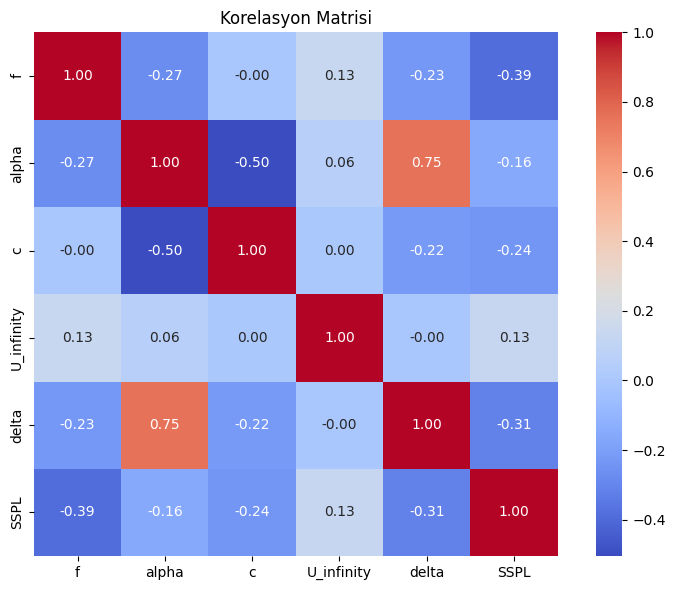

In [4]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.show()

## 3. Eğitim / Test Ayrımı ve Özellik Ölçekleme
SVR, çekirdek fonksiyonu üzerinden **mesafe/nokta çarpımı** hesapladığı
için özelliklerin ölçeği büyük fark yaratır. Bu nedenle hem `X` hem de
hedef değişken `y`, `StandardScaler` ile standartlaştırılır (ortalama=0,
standart sapma=1).

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu  :", X_test.shape)

Eğitim seti boyutu: (1202, 5)
Test seti boyutu  : (301, 5)


In [6]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_scaled.head()

,f,alpha,c,U_infinity,delta
0,-0.586454,0.280030,-0.928823,1.283280,-0.444292
1,-0.273184,-0.011351,-0.385011,1.283280,-0.483640
2,-0.774416,0.948492,-0.385011,0.268982,1.977469
3,-0.774416,1.822634,-1.200729,1.283280,0.385965
4,-0.774416,0.468571,-1.200729,-1.258883,-0.496630


## 4. Doğrusal (Linear) Kernel ile SVR
Linear kernel, veriler arasında doğrudan nokta çarpımı kullanır; ilişki
doğrusala yakınsa tercih edilir. `C` parametresi, modelin hatalara
toleransını (küçük C = daha toleranslı/basit, büyük C = hatalara az
tolerans) kontrol eder. `epsilon`, hata sayılmayan tolerans aralığının
genişliğidir.

In [7]:
svr_linear = SVR(kernel='linear', C=1.0, epsilon=0.1)

svr_linear.fit(X_train_scaled, y_train_scaled)

y_pred_linear_scaled = svr_linear.predict(X_test_scaled)
y_pred_linear = scaler_y.inverse_transform(y_pred_linear_scaled.reshape(-1, 1)).ravel()

linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_r2 = r2_score(y_test, y_pred_linear)

print(f"SVR (Linear) -> MSE: {linear_mse:.2f} | MAE: {linear_mae:.2f} | R2: {linear_r2:.4f}")

SVR (Linear) -> MSE: 22.16 | MAE: 3.52 | R2: 0.5578


## 5. Polinom (Polynomial) Kernel ile SVR
Polynomial kernel, veriyi daha yüksek boyutlu bir uzaya taşıyarak belirli
dereceli doğrusal olmayan ilişkileri modeller. `degree` parametresi
polinom derecesini belirler.

In [8]:
svr_poly = SVR(kernel='poly', C=1.0, epsilon=0.1, degree=3, gamma='scale')

svr_poly.fit(X_train_scaled, y_train_scaled)

y_pred_poly_scaled = svr_poly.predict(X_test_scaled)
y_pred_poly = scaler_y.inverse_transform(y_pred_poly_scaled.reshape(-1, 1)).ravel()

poly_mse = mean_squared_error(y_test, y_pred_poly)
poly_mae = mean_absolute_error(y_test, y_pred_poly)
poly_r2 = r2_score(y_test, y_pred_poly)

print(f"SVR (Poly)   -> MSE: {poly_mse:.2f} | MAE: {poly_mae:.2f} | R2: {poly_r2:.4f}")

SVR (Poly)   -> MSE: 15.92 | MAE: 3.09 | R2: 0.6821


## 6. RBF (Gaussian) Kernel ile SVR
RBF kernel, en sık kullanılan genel amaçlı çekirdektir; karmaşık ve
bilinmeyen doğrusal olmayan ilişkileri esnek şekilde modelleyebilir.
`gamma` parametresi, bir eğitim noktasının etki alanının genişliğini
kontrol eder.

In [9]:
svr_rbf = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')

svr_rbf.fit(X_train_scaled, y_train_scaled)

y_pred_rbf_scaled = svr_rbf.predict(X_test_scaled)
y_pred_rbf = scaler_y.inverse_transform(y_pred_rbf_scaled.reshape(-1, 1)).ravel()

rbf_mse = mean_squared_error(y_test, y_pred_rbf)
rbf_mae = mean_absolute_error(y_test, y_pred_rbf)
rbf_r2 = r2_score(y_test, y_pred_rbf)

print(f"SVR (RBF)    -> MSE: {rbf_mse:.2f} | MAE: {rbf_mae:.2f} | R2: {rbf_r2:.4f}")

SVR (RBF)    -> MSE: 10.06 | MAE: 2.31 | R2: 0.7991


## 7. Model Karşılaştırması

In [10]:
sonuclar = pd.DataFrame({
    "Model": ["SVR (Linear)", "SVR (Poly)", "SVR (RBF)"],
    "MSE": [linear_mse, poly_mse, rbf_mse],
    "MAE": [linear_mae, poly_mae, rbf_mae],
    "R2": [linear_r2, poly_r2, rbf_r2]
})

sonuclar = sonuclar.sort_values("R2", ascending=False)
sonuclar

,Model,MSE,MAE,R2
2,SVR (RBF),10.064471,2.313018,0.799107
1,SVR (Poly),15.924795,3.088444,0.682131
0,SVR (Linear),22.155321,3.521577,0.557765


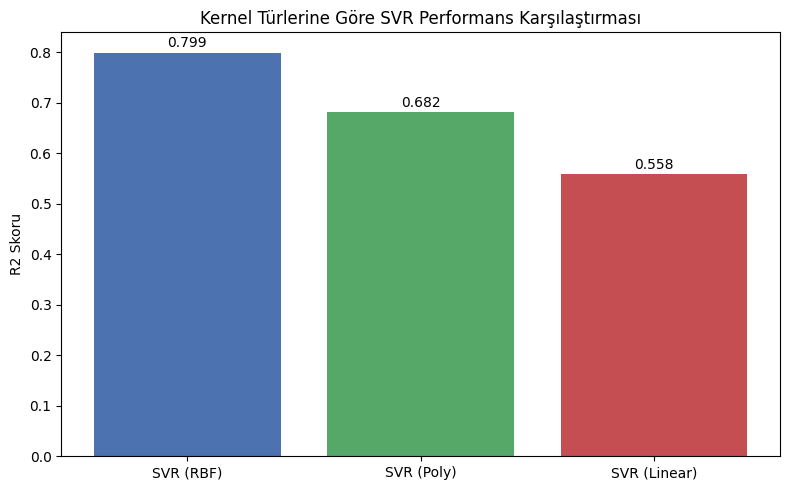

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

modeller = sonuclar["Model"]
skorlar = sonuclar["R2"]

ax.bar(modeller, skorlar, color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_ylabel("R2 Skoru")
ax.set_title("Kernel Türlerine Göre SVR Performans Karşılaştırması")
for i, v in enumerate(skorlar):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()

## 8. GridSearchCV ile Hiperparametre Optimizasyonu
Şimdiye kadar `C`, `epsilon` ve `gamma` değerlerini elle seçtik. Şimdi
çapraz doğrulama (cross-validation) kullanarak en iyi performansı veren
kernel ve hiperparametre kombinasyonunu otomatik olarak bulalım.

In [12]:
param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5],
    'gamma': ['scale', 'auto']
}

svr_grid = GridSearchCV(
    SVR(),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
svr_grid.fit(X_train_scaled, y_train_scaled)

print("En iyi parametreler:", svr_grid.best_params_)
print("En iyi CV R2 skoru :", svr_grid.best_score_)

En iyi parametreler: {'C': 100, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
En iyi CV R2 skoru : 0.8515164835344591


In [13]:
en_iyi_svr = svr_grid.best_estimator_

y_pred_best_scaled = en_iyi_svr.predict(X_test_scaled)
y_pred_best = scaler_y.inverse_transform(y_pred_best_scaled.reshape(-1, 1)).ravel()

best_mse = mean_squared_error(y_test, y_pred_best)
best_mae = mean_absolute_error(y_test, y_pred_best)
best_r2 = r2_score(y_test, y_pred_best)

print(f"SVR (Optimize) -> MSE: {best_mse:.2f} | MAE: {best_mae:.2f} | R2: {best_r2:.4f}")

SVR (Optimize) -> MSE: 6.17 | MAE: 1.69 | R2: 0.8769


## 9. En İyi Model ile Tahmin Görselleştirmesi

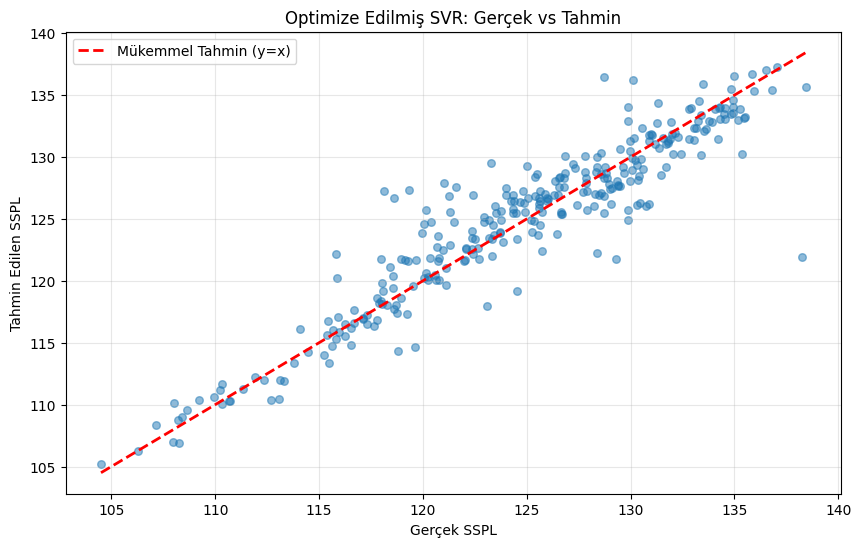

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Mükemmel Tahmin (y=x)')
plt.xlabel('Gerçek SSPL')
plt.ylabel('Tahmin Edilen SSPL')
plt.title('Optimize Edilmiş SVR: Gerçek vs Tahmin')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

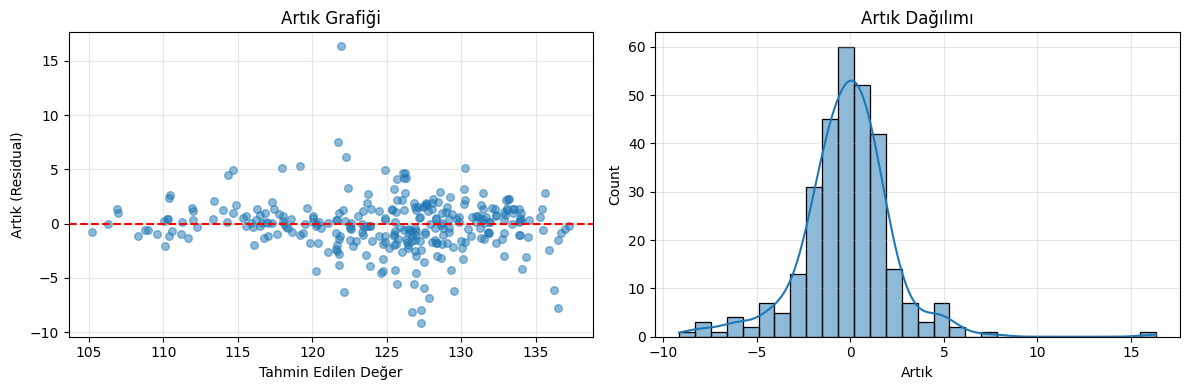

In [15]:
residuals = y_test.values - y_pred_best

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_best, residuals, alpha=0.5, s=30)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Tahmin Edilen Değer')
plt.ylabel('Artık (Residual)')
plt.title('Artık Grafiği')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel('Artık')
plt.title('Artık Dağılımı')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Genel Değerlendirme

- **Linear kernel**: Veri doğrusala yakın bir ilişki göstermiyorsa
  performansı diğer kernellerin gerisinde kalır.
- **Polynomial kernel**: Belirli dereceli doğrusal olmayan ilişkileri
  yakalayabilir, ancak derece arttıkça overfitting riski artar.
- **RBF kernel**: Genelde en esnek ve en iyi performansı veren kerneldir;
  karmaşık, doğrusal olmayan ilişkileri başarıyla modelleyebilir.

`GridSearchCV` ile bulunan optimum `C`, `epsilon`, `gamma` ve kernel
kombinasyonu, elle seçilen değerlere kıyasla genellikle daha iyi
genelleme performansı (test R2) sağlar. Destek vektörleri sayesinde SVR,
epsilon-tüpü içinde kalan noktalardan etkilenmediği için aykırı
değerlere karşı Linear Regression'a göre daha dayanıklıdır.